In [1]:
##### Creates maps of agricultural capital stock and labor (rasters)

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD.tif")
capital_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD_p10.tif")
capital_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD_p90.tif")

labor = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs.tif")
labor_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs_p10.tif")
labor_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs_p90.tif")

country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_capital_labor_raster"

In [3]:
### Data prep

# align crs

crs = "ESRI:54042"

capital = capital.rio.reproject(crs)
capital_p10 = capital_p10.rio.reproject(crs)
capital_p90 = capital_p90.rio.reproject(crs)

labor = labor.rio.reproject(crs)
labor_p10 = labor_p10.rio.reproject(crs)
labor_p90 = labor_p90.rio.reproject(crs)

country_boundaries = country_boundaries.to_crs(crs)

# convert to million 
capital_million = capital / 1e6
capital_million_p10 = capital_p10 / 1e6
capital_million_p90 = capital_p90 / 1e6

labor_thousand = labor / 1e3
labor_thousand_p10 = labor_p10 / 1e3
labor_thousand_p90 = labor_p90 / 1e3

# calculate % differnce 
capital_million_p10_percent_diff = (capital_million_p10 - capital_million) / capital_million
capital_million_p90_percent_diff = (capital_million_p90 - capital_million) / capital_million

labor_million_p10_percent_diff = (labor_thousand_p10 - labor_thousand) / labor_thousand
labor_million_p90_percent_diff = (labor_thousand_p90 - labor_thousand) / labor_thousand

In [4]:
labor_values = labor_thousand.values.flatten()
capital_values = capital_million.values.flatten()

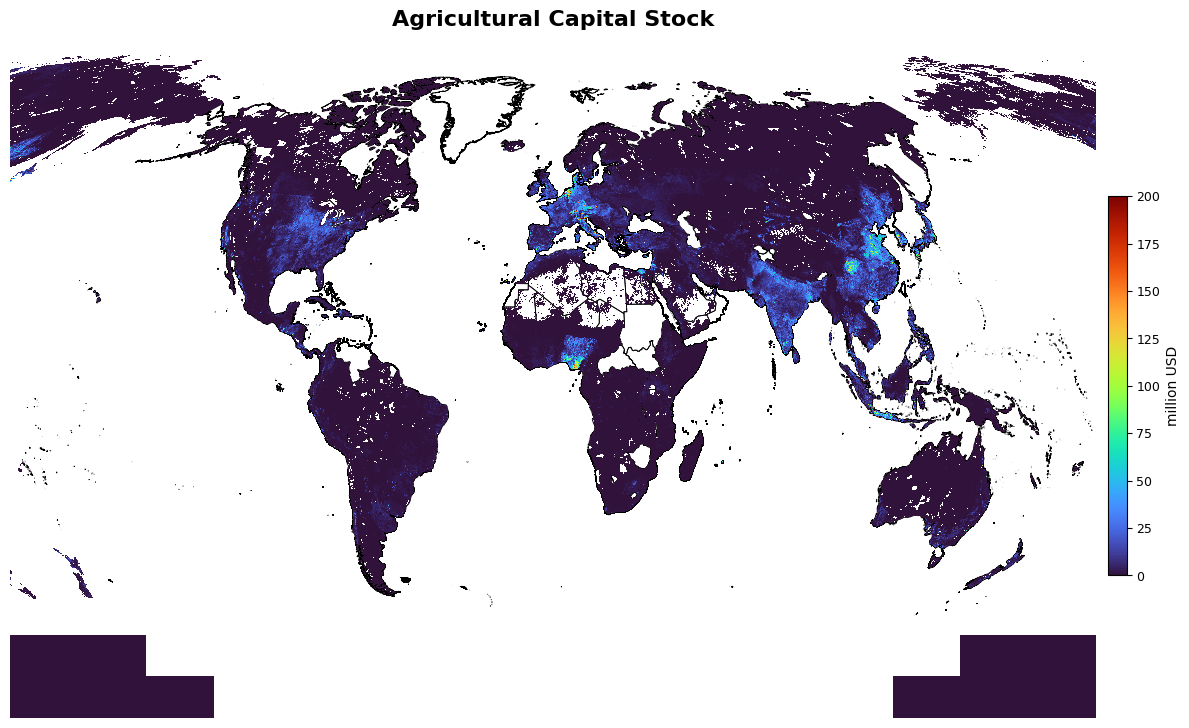

In [24]:
##### Produce global map of capital stock (million USD)

# Prepare raster
capital_plot = capital_million.squeeze()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

# Raster on top
im = capital_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=200,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

ax.set_axis_off()
ax.set_title("Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 25, 50, 75, 100, 125, 150, 175, 200])

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/capital_stock.png", dpi=300, bbox_inches='tight')

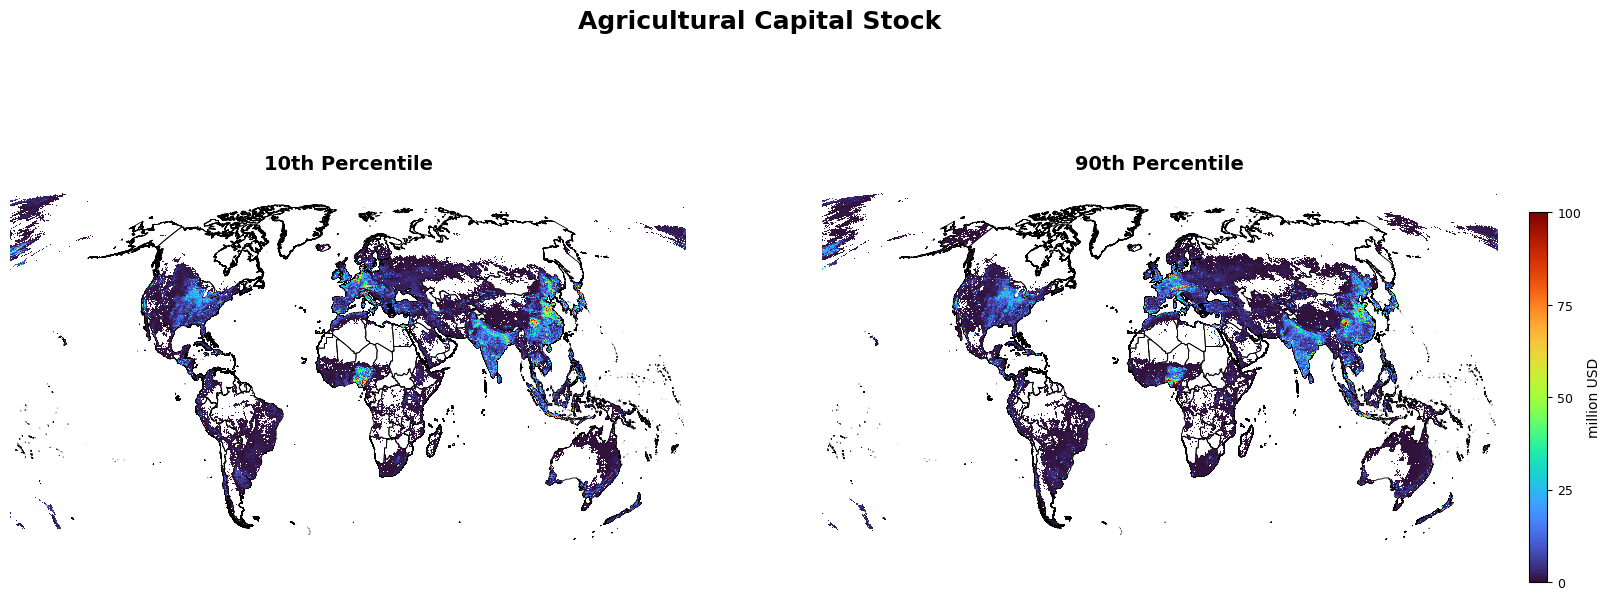

In [21]:
##### Produce global map of capital stock (million USD) — p10 vs p90 side by side

# Prepare rasters
capital_p10_plot = capital_million_p10.squeeze()
capital_p90_plot = capital_million_p90.squeeze()

# Create figure with two panels sharing axes
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

panels = [
    (axes[0], capital_p10_plot, "10th Percentile"),
    (axes[1], capital_p90_plot, "90th Percentile"),
]

for ax, data, subtitle in panels:
    # Country borders underneath
    country_boundaries.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.6,
        zorder=1
    )

    # Raster on top
    im = data.plot(
        ax=ax,
        cmap="turbo",
        vmin=0,
        vmax=200,
        add_colorbar=False,
        add_labels=False,
        zorder=2
    )

    ax.set_axis_off()
    ax.set_title(subtitle, fontsize=14, weight='bold', pad=15)

fig.suptitle("Agricultural Capital Stock", fontsize=18, weight='bold', y=0.98)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.02,
    pad=0.02,
    shrink=0.6
)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 25, 50, 75, 100, 125, 150, 175, 200])

plt.savefig(f"{fd}/capital_stock_p10_p90.png", dpi=300, bbox_inches='tight')
plt.show()

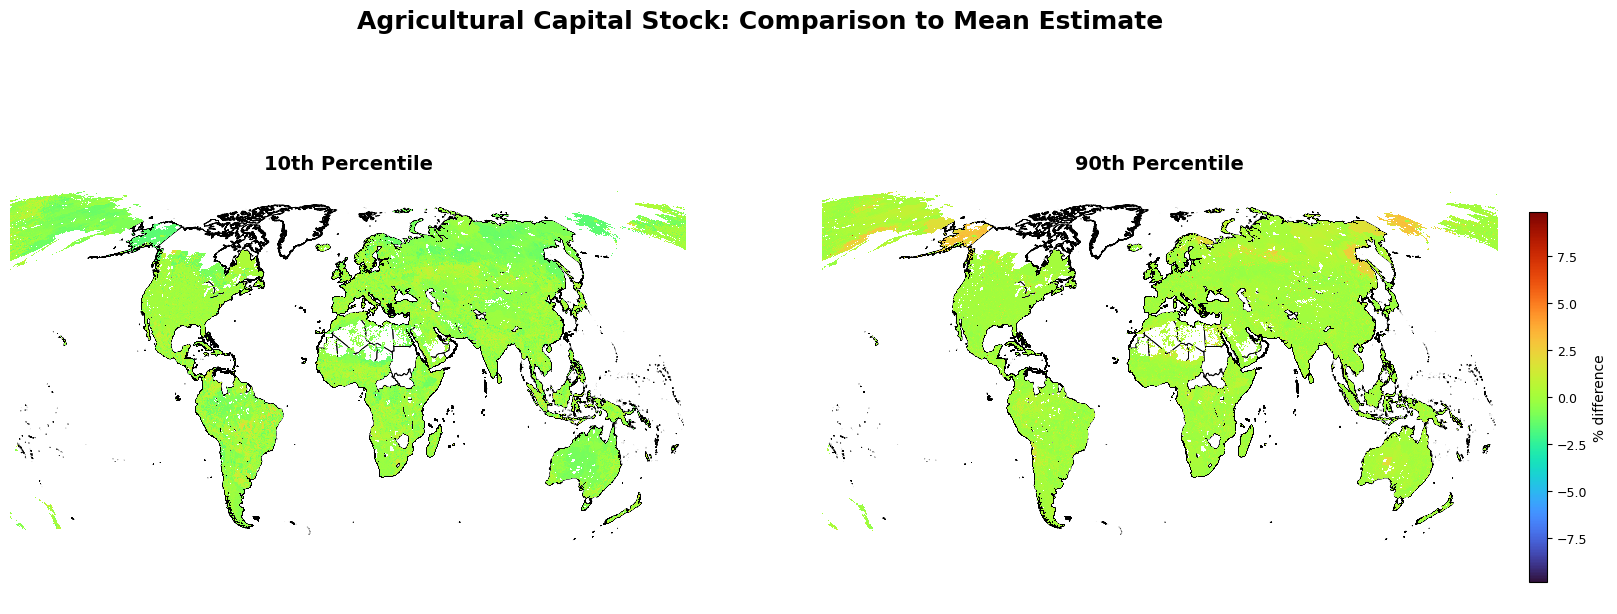

In [8]:
##### Produce global map of p10/p90 vs base map capital stock

# Prepare rasters
capital_million_p10_percent_diff_plot = capital_million_p10_percent_diff.squeeze()
capital_million_p90_percent_diff_plot = capital_million_p90_percent_diff.squeeze()

# Create figure with two panels sharing axes
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

panels = [
    (axes[0], capital_million_p10_percent_diff_plot, "10th Percentile"),
    (axes[1], capital_million_p90_percent_diff_plot, "90th Percentile"),
]

for ax, data, subtitle in panels:
    # Country borders underneath
    country_boundaries.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.6,
        zorder=1
    )

    # Raster on top
    im = data.plot(
        ax=ax,
        cmap="turbo",
        add_colorbar=False,
        add_labels=False,
        zorder=2
    )

    ax.set_axis_off()
    ax.set_title(subtitle, fontsize=14, weight='bold', pad=15)

fig.suptitle("Agricultural Capital Stock: Comparison to Mean Estimate", fontsize=18, weight='bold', y=0.98)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.02,
    pad=0.02,
    shrink=0.6
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.savefig(f"{fd}/capital_stock_p10_p90_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

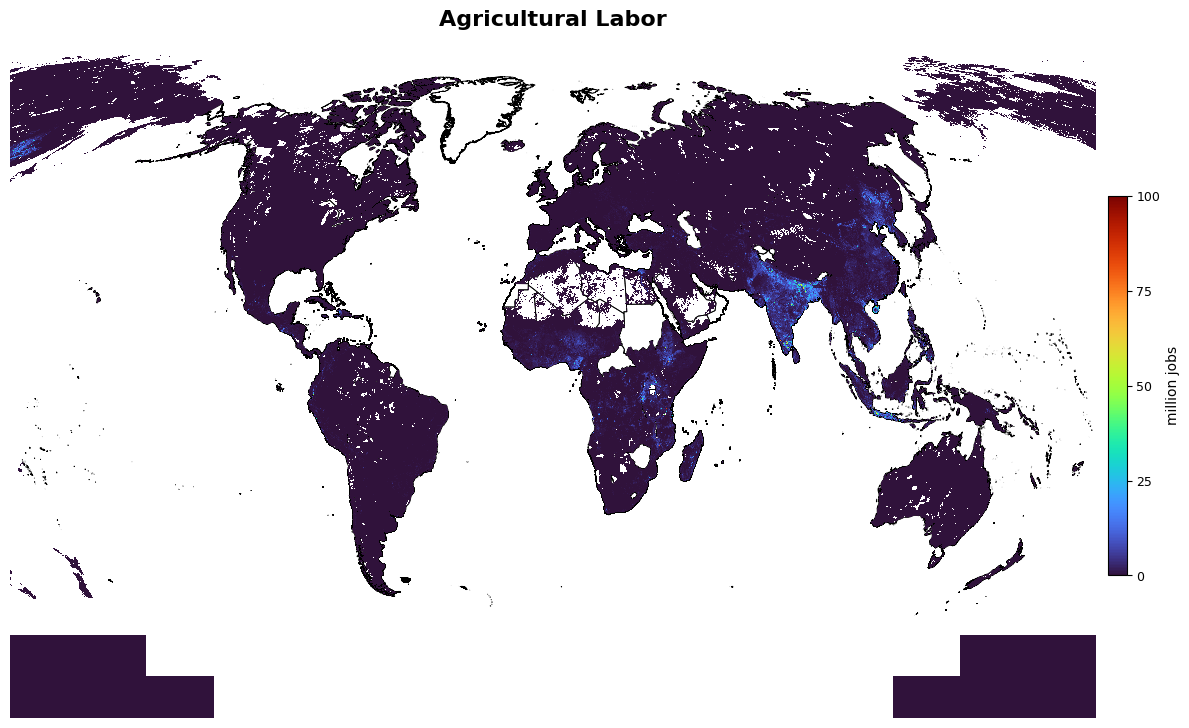

In [7]:
##### Produce global map of labor (million jobs)

# Prepare raster
labor_plot = labor_thousand.squeeze()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

# Raster on top
im = labor_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=100,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

ax.set_axis_off()
ax.set_title("Agricultural Labor", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million jobs", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 25, 50, 75, 100])

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/labor.png", dpi=300, bbox_inches='tight')

In [ ]:
##### Produce global map of capital stock (million USD) — p10 vs p90 side by side

# Prepare rasters
labor_p10_plot = labor_thousand_p10.squeeze()
labor_p90_plot = labor_thousand_p90.squeeze()

# Create figure with two panels sharing axes
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

panels = [
    (axes[0], labor_p10_plot, "10th Percentile"),
    (axes[1], labor_p90_plot, "90th Percentile"),
]

for ax, data, subtitle in panels:
    # Country borders underneath
    country_boundaries.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.6,
        zorder=1
    )

    # Raster on top
    im = data.plot(
        ax=ax,
        cmap="turbo",
        vmin=0,
        vmax=200,
        add_colorbar=False,
        add_labels=False,
        zorder=2
    )

    ax.set_axis_off()
    ax.set_title(subtitle, fontsize=14, weight='bold', pad=15)

fig.suptitle("Agricultural Labor", fontsize=18, weight='bold', y=0.98)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.02,
    pad=0.02,
    shrink=0.6
)
cbar.set_label("million jobs", fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 25, 50, 75, 100, 125, 150, 175, 200])

plt.savefig(f"{fd}/labor_p10_p90.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
##### Produce global map of p10/p90 vs base map labor

# Prepare rasters
labor_million_p10_percent_diff_plot = labor_million_p10_percent_diff.squeeze()
labor_million_p90_percent_diff_plot = labor_million_p90_percent_diff.squeeze()

# Create figure with two panels sharing axes
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True, sharey=True)

panels = [
    (axes[0], labor_million_p10_percent_diff_plot, "10th Percentile"),
    (axes[1], labor_million_p90_percent_diff_plot, "90th Percentile"),
]

for ax, data, subtitle in panels:
    # Country borders underneath
    country_boundaries.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.6,
        zorder=1
    )

    # Raster on top
    im = data.plot(
        ax=ax,
        cmap="turbo",
        add_colorbar=False,
        add_labels=False,
        zorder=2
    )

    ax.set_axis_off()
    ax.set_title(subtitle, fontsize=14, weight='bold', pad=15)

fig.suptitle("Agricultural Labor: Comparison to Mean Estimate", fontsize=18, weight='bold', y=0.98)

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    fraction=0.02,
    pad=0.02,
    shrink=0.6
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.savefig(f"{fd}/labor_p10_p90_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
##### Produce regional map of capital stock

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=1
)

# Raster on top
im = capital_masked.plot(
    ax=ax,
    cmap="turbo",
    vmin=0.1,
    vmax=250,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

transformer = Transformer.from_crs("EPSG:4326", "ESRI:54042", always_xy=True)

# Set bbox for region of interest 

# Europe
minx, miny = transformer.transform(-15.108776, 41.834654)
maxx, maxy = transformer.transform(31.868763, 59.016438)

# # Egypt & the Levant 
# minx, miny = transformer.transform(23.819561, 21.459939)
# maxx, maxy = transformer.transform(40.167217, 36.037301)

# # Colombia & Venezuela
# minx, miny = transformer.transform(-80.024414,-2.108899)
# maxx, maxy = transformer.transform(-59.677734,13.923404)

# # China and East Asia 
# minx, miny = transformer.transform(98.026886,20.106878)
# maxx, maxy = transformer.transform(150.409698,46.049884)

# # East Africa
# minx, miny = transformer.transform(27.421875,-5.747174)
# maxx, maxy = transformer.transform(43.637695,5.353521)

# # Continental US
# minx, miny = transformer.transform(-130.609589,20.777383)
# maxx, maxy = transformer.transform(-66.976776,49.675182)

# Rest
ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])   

ax.set_axis_off()

plt.tight_layout()
plt.show()